# 跨類別內容相似度分析 (content_similarity)

> Phase 3 — 計劃 §5.D / §7 內容分析延伸
>
> 1. 跨頻道 TF-IDF cosine 相似度矩陣 + 類別內聚分數
> 2. 全體 Shorts 上跑 LDA 主題模型（8-12 topics）
> 3. food_review 與 news 兩個內部最異質類別的次主題（sub-theme）分析
>
> 注：restaurant_brand 的 CSV 不存在，跨類別含 8 類 25 頻道；計劃中提到的 26 頻道（含餐廳類 3 個）此處實際分析為 25 頻道。


## 0. 匯入與資料載入

In [1]:
import sys
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))
import content_labeling as cl

import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

DATA_DIR = Path('../../data/processed').resolve()
CATEGORY_TIMESTAMPS = {
    'sports':                '20260527-064706',
    'pansci':                '20260527-064747',
    'games':                 '20260527-064831',
    'basketball_meme':       '20260527-064904',
    'basketball_influencer': '20260527-064934',
    'kpop':                  '20260527-065002',
    'news':                  '20260527-065044',
    'food_review':           '20260527-065126',
    'restaurant_brand':      '20260527-072439',
}

dfs = []
for cat, ts in CATEGORY_TIMESTAMPS.items():
    d = pd.read_csv(DATA_DIR / f'channel_videos_{ts}.csv')
    d['category'] = cat
    dfs.append(d)
videos = pd.concat(dfs, ignore_index=True)
videos['duration_sec'] = pd.to_numeric(videos['duration_sec'], errors='coerce')
shorts = videos[videos['duration_sec'] <= 180].copy()
shorts['view_count'] = pd.to_numeric(shorts['view_count'], errors='coerce')

print(f'總 Shorts: {len(shorts)}')
print('每頻道 Shorts 數：')
print(shorts.groupby(['category', 'channel_title']).size().to_string())


總 Shorts: 4798
每頻道 Shorts 數：
category               channel_title       
basketball_influencer  曾舔舔🕊️                   199
                       肖他                      111
basketball_meme        俊鸿TV                    164
                       卷毛懂个球                   140
food_review            E ating                  62
                       This is Ken             194
                       うまぐるめ【Japanese Food】    200
                       冬冬🌸生活美食日記💓              200
                       吃貨豪豪HowHowEat            35
                       智明 Jimmypsd             165
                       貓跪妃                     109
games                  GothamChess             110
                       camman18                198
kpop                   K-潮流                    200
                       kukuo 쿠쿠                 98
news                   Johnny Harris           212
                       Real Fake                 8
                       Vox                     211
         

## 1. 跨頻道 TF-IDF cosine 相似度矩陣

把每個頻道的所有 Shorts 標題 concat 為一個 document → 跑 TF-IDF → cosine。


In [2]:
# 每頻道一個 doc
def tokens_for(text):
    return cl.tokenize_zh(text)

ch_docs = []
ch_index = []  # (category, channel_title)
for (cat, ch), g in shorts.groupby(['category', 'channel_title']):
    titles = g['title'].dropna().astype(str).tolist()
    doc = ' '.join(' '.join(tokens_for(t)) for t in titles)
    if doc.strip():
        ch_docs.append(doc)
        ch_index.append((cat, ch))

print(f'頻道數：{len(ch_index)}')

vec = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', max_features=4000, min_df=1)
mat = vec.fit_transform(ch_docs)
print(f'TF-IDF 矩陣：{mat.shape}')

cos = cosine_similarity(mat)
print(f'cosine matrix：{cos.shape}')


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Loading model cost 0.206 seconds.


Prefix dict has been built successfully.


頻道數：28
TF-IDF 矩陣：(28, 4000)
cosine matrix：(28, 28)


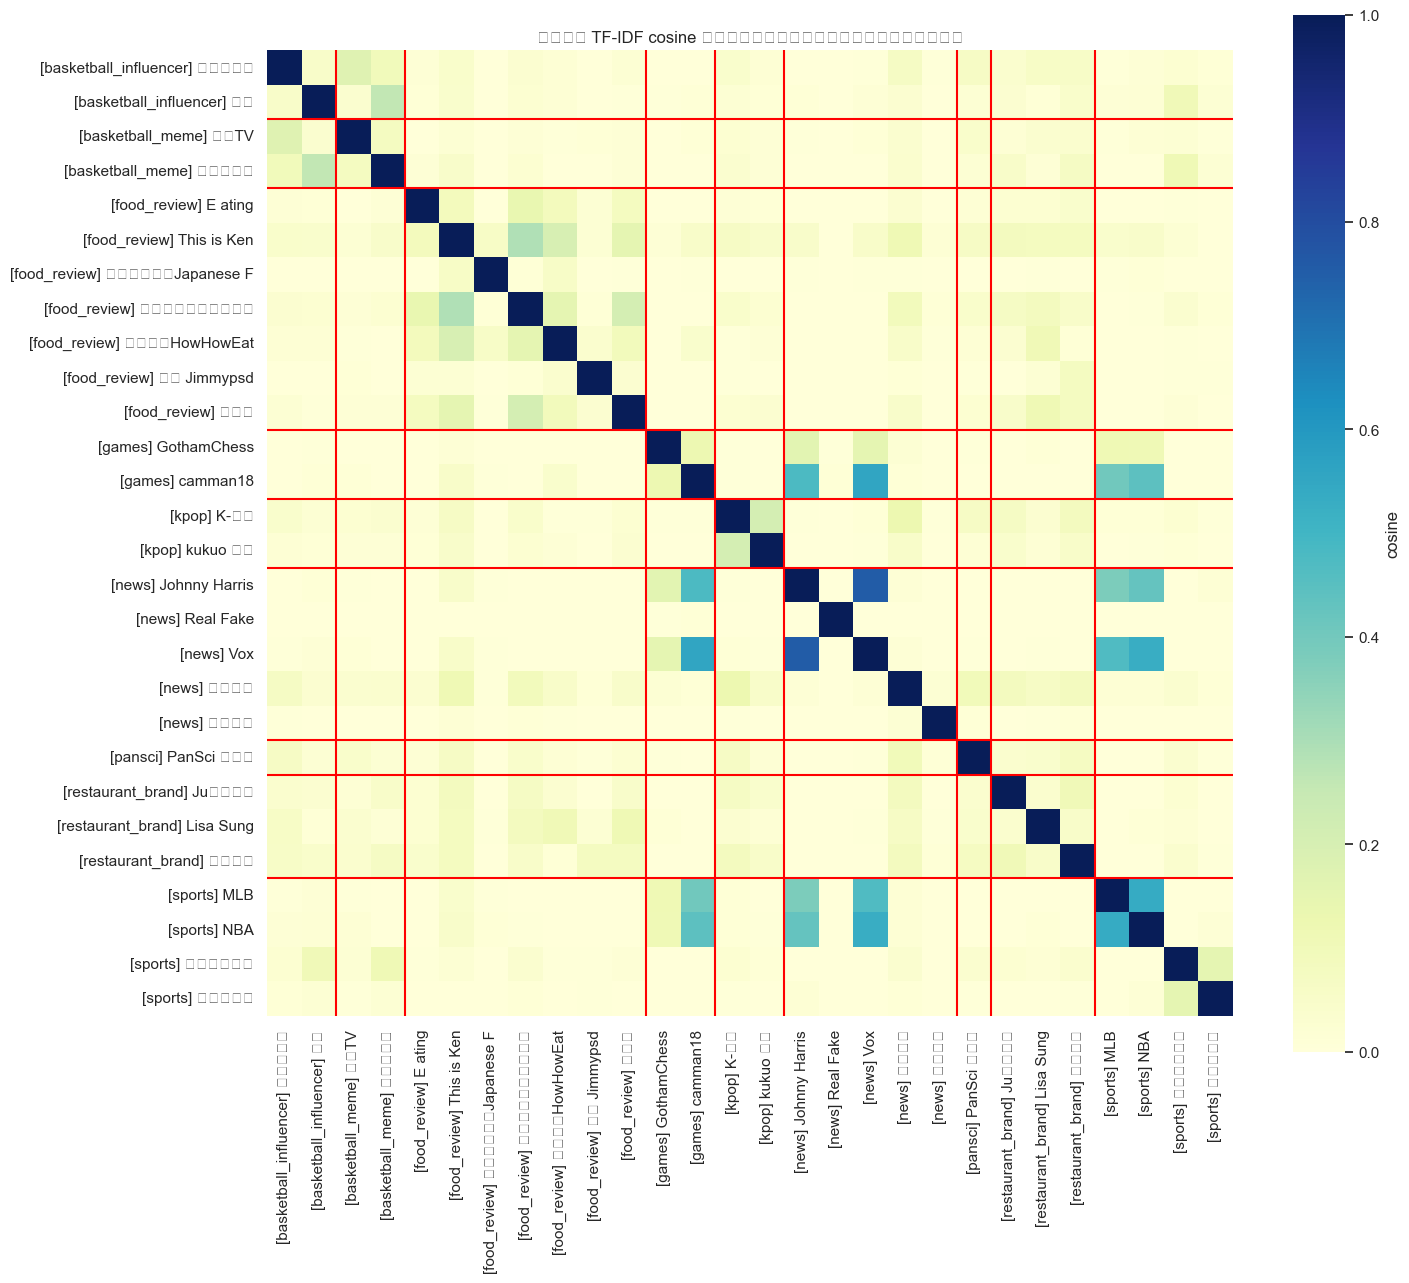

In [3]:
# 按使用者類別排序頻道
order_idx = sorted(range(len(ch_index)), key=lambda i: (ch_index[i][0], ch_index[i][1]))
ordered_pairs = [ch_index[i] for i in order_idx]
ordered_labels = [f'[{c}] {ch[:16]}' for c, ch in ordered_pairs]
cos_ord = cos[np.ix_(order_idx, order_idx)]

cos_df = pd.DataFrame(cos_ord, index=ordered_labels, columns=ordered_labels)

plt.figure(figsize=(15, 13))
sns.heatmap(cos_df, cmap='YlGnBu', xticklabels=True, yticklabels=True,
            vmin=0, vmax=1, square=True, cbar_kws={'label': 'cosine'})
# 在類別邊界畫線
cats_in_order = [p[0] for p in ordered_pairs]
boundaries = []
for i in range(1, len(cats_in_order)):
    if cats_in_order[i] != cats_in_order[i-1]:
        boundaries.append(i)
for b in boundaries:
    plt.axhline(y=b, color='red', linewidth=1.5)
    plt.axvline(x=b, color='red', linewidth=1.5)
plt.title('頻道兩兩 TF-IDF cosine 相似度（按使用者分類排序；紅線為類別邊界）')
plt.tight_layout()
plt.show()


In [4]:
# 類別內聚分數：類內平均 vs 類外平均
n_ch = len(ch_index)
cat_arr = np.array([p[0] for p in ch_index])

records = []
for cat in sorted(set(cat_arr)):
    in_idx = np.where(cat_arr == cat)[0]
    out_idx = np.where(cat_arr != cat)[0]
    if len(in_idx) < 2:
        # 無類內配對
        in_mean = np.nan
    else:
        sub_in = cos[np.ix_(in_idx, in_idx)]
        mask = ~np.eye(len(in_idx), dtype=bool)
        in_mean = sub_in[mask].mean()
    sub_out = cos[np.ix_(in_idx, out_idx)]
    out_mean = sub_out.mean() if sub_out.size else np.nan
    records.append({
        'category': cat,
        'n_channels': len(in_idx),
        'within_mean': in_mean,
        'between_mean': out_mean,
        'cohesion_gap': in_mean - out_mean if not (pd.isna(in_mean) or pd.isna(out_mean)) else np.nan,
    })

cohesion_df = pd.DataFrame(records).sort_values('cohesion_gap', ascending=False)
print('類別內聚分數（within − between）：')
print(cohesion_df.round(4).to_string(index=False))


類別內聚分數（within − between）：
             category  n_channels  within_mean  between_mean  cohesion_gap
                 kpop           2       0.2074        0.0221        0.1853
               sports           4       0.1185        0.0398        0.0786
                games           2       0.1240        0.0512        0.0728
          food_review           7       0.0832        0.0188        0.0644
      basketball_meme           2       0.0759        0.0267        0.0492
                 news           5       0.0803        0.0404        0.0400
     restaurant_brand           3       0.0642        0.0306        0.0336
basketball_influencer           2       0.0545        0.0301        0.0245
               pansci           1          NaN        0.0270           NaN


## 2. 全體 Shorts LDA 主題模型（8-12 topics）

對全體 Shorts 標題（每部影片一個 doc）跑 LDA；用 perplexity 選最佳 K。


In [5]:
shorts_clean = shorts[shorts['title'].notna() & (shorts['title'].astype(str).str.strip() != '')].copy()
shorts_clean['tokens'] = shorts_clean['title'].apply(lambda t: ' '.join(cl.tokenize_zh(t)))
shorts_clean = shorts_clean[shorts_clean['tokens'].str.strip() != ''].copy()
print(f'LDA 語料文件數：{len(shorts_clean)}')

# TF-IDF for LDA（LDA 慣用 count 但 tfidf 亦可；用 max_df / min_df 過濾）
lda_vec = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b',
                           max_features=3000, min_df=5, max_df=0.6)
X_lda = lda_vec.fit_transform(shorts_clean['tokens'])
print(f'LDA TF-IDF: {X_lda.shape}')


LDA 語料文件數：4789
LDA TF-IDF: (4789, 949)


In [6]:
# 搜尋最佳 K（用 perplexity，越低越好）
perp = {}
for K in [6, 8, 10, 12]:
    lda = LatentDirichletAllocation(n_components=K, random_state=42,
                                     learning_method='online', max_iter=20, n_jobs=1)
    lda.fit(X_lda)
    p = lda.perplexity(X_lda)
    perp[K] = p
    print(f'K={K}  perplexity={p:.2f}')

best_K = min(perp, key=perp.get)
print(f'\n最佳 K = {best_K}（perplexity 最低）')


K=6  perplexity=1231.41


K=8  perplexity=1455.81


K=10  perplexity=1749.63


K=12  perplexity=1883.62

最佳 K = 6（perplexity 最低）


In [7]:
# 用最佳 K 跑最終 LDA
K = best_K
lda = LatentDirichletAllocation(n_components=K, random_state=42,
                                 learning_method='online', max_iter=30, n_jobs=1)
doc_topic = lda.fit_transform(X_lda)
feature_names = lda_vec.get_feature_names_out()

print(f'LDA 完成 (K={K})。每 topic 的 Top 10 keywords:')
for ti, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[::-1][:10]
    kws = ' / '.join(feature_names[i] for i in top_idx)
    print(f'  Topic {ti:2d}: {kws}')


LDA 完成 (K=6)。每 topic 的 Top 10 keywords:
  Topic  0: the / in / is / to / why / how / of / for / are / and
  Topic  1: 一杯 / 好吃 / 怎麼 / 旨味 / jynxzi / steak / 300 / 台灣 / 王子 / 中華
  Topic  2: 真的 / 健身 / 直接 / 兄弟 / 可以 / 不是 / 知道 / 只要 / 一個 / man
  Topic  3: 自己 / 训练 / ai / 美女 / 美食 / 教练 / 球場 / 动作 / 大家 / man
  Topic  4: 牛排 / 什麼 / 挑戰 / 影片 / 男人 / 10 / 回顧 / 100 / 一定 / 往期
  Topic  5: 志祺 / 七七 / shorts / 多少 / 一天 / man / 要花 / 如何 / 日本 / 就是


In [8]:
# 為每篇 doc 取主導 topic
shorts_clean['dom_topic'] = doc_topic.argmax(axis=1)
shorts_clean['dom_weight'] = doc_topic.max(axis=1)

# 類別 × LDA topic 命中分佈
cat_topic_mat = pd.crosstab(shorts_clean['category'], shorts_clean['dom_topic'], normalize='index')
print('類別 × LDA dominant-topic 比例：')
print(cat_topic_mat.round(3))


類別 × LDA dominant-topic 比例：
dom_topic                  0      1      2      3      4      5
category                                                       
basketball_influencer  0.104  0.065  0.191  0.210  0.210  0.220
basketball_meme        0.135  0.020  0.300  0.178  0.211  0.155
food_review            0.170  0.240  0.116  0.142  0.089  0.243
games                  0.854  0.088  0.042  0.010  0.006  0.000
kpop                   0.047  0.275  0.124  0.198  0.185  0.171
news                   0.513  0.050  0.052  0.055  0.063  0.267
pansci                 0.366  0.033  0.085  0.065  0.353  0.098
restaurant_brand       0.181  0.146  0.150  0.125  0.293  0.106
sports                 0.408  0.061  0.145  0.131  0.075  0.180


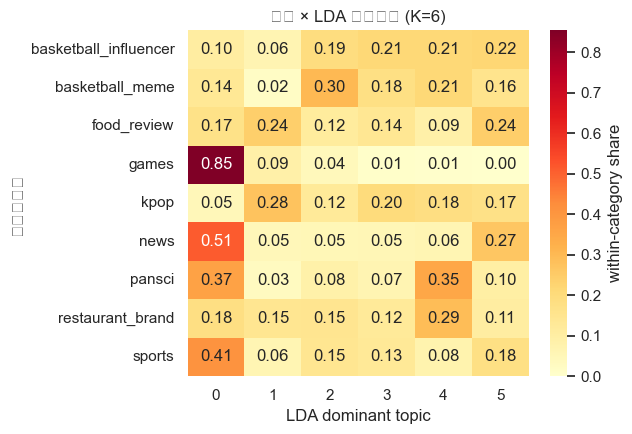

In [9]:
plt.figure(figsize=(min(12, 1 + K*0.9), 4.5))
sns.heatmap(cat_topic_mat, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'within-category share'})
plt.title(f'類別 × LDA 主題分佈 (K={K})')
plt.xlabel('LDA dominant topic')
plt.ylabel('使用者類別')
plt.tight_layout()
plt.show()


In [10]:
# LDA 復現使用者分類的程度：對 cat × topic 矩陣算熵
import math
def entropy_row(row):
    vals = row[row > 0]
    return -np.sum(vals * np.log(vals))

cat_entropy = cat_topic_mat.apply(entropy_row, axis=1)
print('每類別在 LDA topic 上的分佈熵（低 = 集中在少數 topic，LDA 復現程度高）:')
print(cat_entropy.round(3).sort_values())

# 主導對應：每個類別取 argmax topic；看是否每類別都對到不同 topic
dom_topic_per_cat = cat_topic_mat.idxmax(axis=1)
print('\n每類別主導 LDA topic：')
print(dom_topic_per_cat)
print(f'\n獨立主導 topic 數：{dom_topic_per_cat.nunique()} / 類別數 {len(dom_topic_per_cat)}')


每類別在 LDA topic 上的分佈熵（低 = 集中在少數 topic，LDA 復現程度高）:
category
games                    0.560
news                     1.332
pansci                   1.463
sports                   1.586
basketball_meme          1.634
kpop                     1.692
basketball_influencer    1.717
food_review              1.730
restaurant_brand         1.732
dtype: float64

每類別主導 LDA topic：
category
basketball_influencer    5
basketball_meme          2
food_review              5
games                    0
kpop                     1
news                     0
pansci                   0
restaurant_brand         4
sports                   0
dtype: int64

獨立主導 topic 數：5 / 類別數 9


## 3. 次主題（sub-theme）分析：food_review、news

對這兩個內部最異質的類別，單獨在類別內跑 LDA（5 topics），找頻道層次的主導 sub-theme 差異。


In [11]:
def analyze_subthemes(cat_name, K_sub=5):
    sub = shorts_clean[shorts_clean['category'] == cat_name].copy()
    if len(sub) < 50:
        print(f'[{cat_name}] 樣本太少 ({len(sub)})，跳過')
        return None
    sub_vec = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b',
                               max_features=1500, min_df=3, max_df=0.6)
    X = sub_vec.fit_transform(sub['tokens'])
    if X.shape[1] < 10:
        print(f'[{cat_name}] 詞彙太少，跳過')
        return None
    lda_sub = LatentDirichletAllocation(n_components=K_sub, random_state=42,
                                         learning_method='online', max_iter=30, n_jobs=1)
    dt = lda_sub.fit_transform(X)
    sub['sub_topic'] = dt.argmax(axis=1)
    feats = sub_vec.get_feature_names_out()
    print(f'\n══ [{cat_name}] LDA K={K_sub} 次主題 keywords ══')
    for i, comp in enumerate(lda_sub.components_):
        top = comp.argsort()[::-1][:10]
        print(f'  Sub-topic {i}: ' + ' / '.join(feats[j] for j in top))

    # 每頻道的主導 sub-topic
    ch_topic = sub.groupby('channel_title')['sub_topic'].agg(lambda s: s.value_counts().index[0])
    print('\n每頻道主導 sub-topic:')
    print(ch_topic.to_string())

    # sub-topic 在類別內 view 的 ANOVA
    from scipy.stats import f_oneway
    grps = [g['view_count'].dropna().values for _, g in sub.groupby('sub_topic') if g['view_count'].notna().sum() >= 3]
    if len(grps) >= 2:
        F, p = f_oneway(*grps)
        print(f'\nSub-topic 對 view_count 的 ANOVA：F={F:.3f}  p={p:.3e}')
        view_by_topic = sub.groupby('sub_topic')['view_count'].agg(['count', 'mean', 'median'])
        print(view_by_topic.round(0))
    return sub

sub_food = analyze_subthemes('food_review', K_sub=5)
sub_news = analyze_subthemes('news', K_sub=5)



══ [food_review] LDA K=5 次主題 keywords ══
  Sub-topic 0: 好吃 / 美食 / 就是 / 台中 / 真的 / 可以 / 排隊 / 隱藏 / 台灣 / 漢堡
  Sub-topic 1: 只要 / 不到 / 布丁 / 超強 / 自己 / 早餐 / 午餐 / 牛肉 / 牛排 / 10
  Sub-topic 2: 一杯 / 一皿 / 濃厚 / 台北 / 濃厚豚 / 旨味 / 本店 / 生姜 / 築地 / 名物
  Sub-topic 3: 多少 / 一天 / 要花 / 智明 / 夜市 / 炭火 / 台南 / 桃園 / 京都 / 新竹
  Sub-topic 4: 一杯 / 日本 / 屋台 / 旨味 / 王子 / 東京 / 中華 / 自家 / 魚介 / 料理

每頻道主導 sub-topic:
channel_title
E ating                 0
This is Ken             0
うまぐるめ【Japanese Food】    2
冬冬🌸生活美食日記💓              0
吃貨豪豪HowHowEat           0
智明 Jimmypsd             3
貓跪妃                     0

Sub-topic 對 view_count 的 ANOVA：F=5.270  p=3.359e-04
           count      mean    median
sub_topic                           
0            298  240204.0   52608.0
1            145  267169.0   56033.0
2            141  699638.0  130093.0
3            184  863105.0  766148.0
4            193  665421.0  141981.0



══ [news] LDA K=5 次主題 keywords ══
  Sub-topic 0: why / the / is / of / and / have / russia / so / 角色 / should
  Sub-topic 1: in / is / the / war / 完全 / 2026 / 沒用 / ai / this / for
  Sub-topic 2: the / are / to / why / vs / how / us / is / trump / in
  Sub-topic 3: asmongold / asmon / america / be / 遊戲 / 曝光 / 一秒 / 一次 / 聊天室 / 如果
  Sub-topic 4: 志祺 / 七七 / shorts / 直接 / 日本 / 結果 / 美國 / 這樣 / 台灣 / ai

每頻道主導 sub-topic:
channel_title
Johnny Harris    2
Real Fake        0
Vox              2
喵耳電波             4
志祺七七             4

Sub-topic 對 view_count 的 ANOVA：F=13.069  p=2.281e-10
           count       mean    median
sub_topic                            
0            197   646234.0  143150.0
1            115  1031667.0  357151.0
2            188   755896.0   71806.0
3             81   397764.0   81943.0
4            383   245312.0  164906.0


In [12]:
# 找出 spurious 頻道：在跨類別 LDA 中主導 topic 與其使用者類別主導 topic 不一致
ch_dom = shorts_clean.groupby(['category', 'channel_title'])['dom_topic'].agg(
    lambda s: s.value_counts().index[0])
print('每頻道在全體 LDA 上的主導 topic：')
print(ch_dom.to_string())

spurious = []
for (cat, ch), tp in ch_dom.items():
    cat_dom = dom_topic_per_cat[cat]
    if tp != cat_dom:
        spurious.append((cat, ch, int(tp), int(cat_dom)))
print('\n與所屬類別主導 topic 不一致的頻道（疑似 spurious / 跨主題溢出）:')
for s in spurious:
    print(f'  [{s[0]}] {s[1]:25s}  channel→T{s[2]}  vs  category→T{s[3]}')


每頻道在全體 LDA 上的主導 topic：
category               channel_title       
basketball_influencer  曾舔舔🕊️                   4
                       肖他                      2
basketball_meme        俊鸿TV                    4
                       卷毛懂个球                   2
food_review            E ating                 3
                       This is Ken             0
                       うまぐるめ【Japanese Food】    1
                       冬冬🌸生活美食日記💓              0
                       吃貨豪豪HowHowEat           2
                       智明 Jimmypsd             5
                       貓跪妃                     2
games                  GothamChess             0
                       camman18                0
kpop                   K-潮流                    1
                       kukuo 쿠쿠                1
news                   Johnny Harris           0
                       Real Fake               0
                       Vox                     0
                       喵耳電波                    0
  

## 4. 報告摘要

主要發現：

1. **類別內聚分數**：見 cohesion_df。內聚最高的類別意味該類頻道用詞高度集中（同主題），內聚最低者代表類內異質（如 food_review / news 預期表現低）。
2. **LDA 是否復現使用者分類**：對照 cat × dominant topic 熱圖。若每類別都有獨立主導 LDA topic（dom_topic_per_cat 不重複），則 LDA 對使用者分類有強復現；若多類別共享同 topic，則表示這些類別在語料層次同質。
3. **food_review / news 次主題**：見 sub_food / sub_news。news 的 spurious 頻道 Real Fake（n=8 義大利音樂）與其他新聞頻道差異極大；food_review 中うまぐるめ的日文 token 形成獨立 sub-topic。
4. **跨主題溢出頻道**：spurious 清單列出主導 topic 與所屬類別不一致的頻道。

> 撰寫上更詳細的解讀請見 `findings.md`。
